In [ ]:
import random
import csv
import torch
from torch import nn
import pandas as pd
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# generate data
from genData.SSM import *

# SC, RSC
from matrix import Matrix 
from synthetic_control import SyntheticControl

# TASC
from tasc import TimeAwareSC 

# CIM
import tensorflow as tf
import tensorflow_probability as tfp
import causalimpact


# only for notebook
import matplotlib.pyplot as plt

2025-09-24 17:52:10.868843: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 17:52:10.910189: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 17:52:11.966548: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)              # Python random
    # np.random.seed(seed)           # NumPy (if used anywhere)
    torch.manual_seed(seed)        # Torch CPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # All CUDA devices

    # For full reproducibility (slows down training a bit)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
def synthetic_control_prediction(Y, T, T0):
    Y_mask = Y.copy()
    Y_mask[T0:, 0] = [None] * (T - T0)
    df = pd.DataFrame(Y_mask)
    M = Matrix(df, T0, target_name=0)
    sys = SyntheticControl()
    sys.fit(M.pre_donor, M.pre_target, method='simplex')
    sc_pred = np.array(sys.predict(M.donor)).squeeze()
    return sc_pred

def rsc_prediction(Y, T, T0, d, rscmethod='ridge', rsclmbda=0.1, bad_states=None):
    Y_mask = Y.copy()
    Y_mask[T0:, 0] = [None] * (T - T0)
    df = pd.DataFrame(Y_mask)
    M = Matrix(df, T0, target_name=0)
    M.denoise(num_sv=d)
    sys = SyntheticControl()
    sys.fit(M.pre_donor, M.pre_target, method=rscmethod, lmbda=rsclmbda)
    rsc_pred = np.array(sys.predict(M.donor)).squeeze()
    return rsc_pred

def cim_prediction(Y, T, T0):
    Y_mask = Y.copy()
    Y_mask[T0:, 0] = [None] * (T - T0)  # You can sikip this to use causalimpact.plot(impact)
    df = pd.DataFrame(Y_mask, columns=["y"]+[f"x{i}" for i in range(N-1)])
    pre_period = (0, T0-1)
    post_period = (T0, T-1)
    impact = causalimpact.fit_causalimpact(
        data=df,
        pre_period=pre_period,
        post_period=post_period)
    cim_pred = np.array(impact.series['posterior_mean']).squeeze()
    posterior_lower = impact.series["posterior_lower"]
    posterior_upper = impact.series["posterior_upper"]
    return impact, cim_pred, posterior_lower, posterior_upper


class IndexShuffler:
    def __init__(self, n, seed=None):
        """
        Create a shuffler for indices [0, 1, ..., n-1].
        """
        self.n = n
        rng = np.random.default_rng(seed)
        self.permutation = rng.permutation(n)
        # Inverse permutation to go back
        self.inverse = np.argsort(self.permutation)


[[ 43.06682589 -23.67007593]
 [-23.67007593  13.0985382 ]]
[[ 25.14242039   5.70300029 -25.47642506]
 [  5.70300029  19.58057061  19.2492935 ]
 [-25.47642506  19.2492935   60.06896066]]


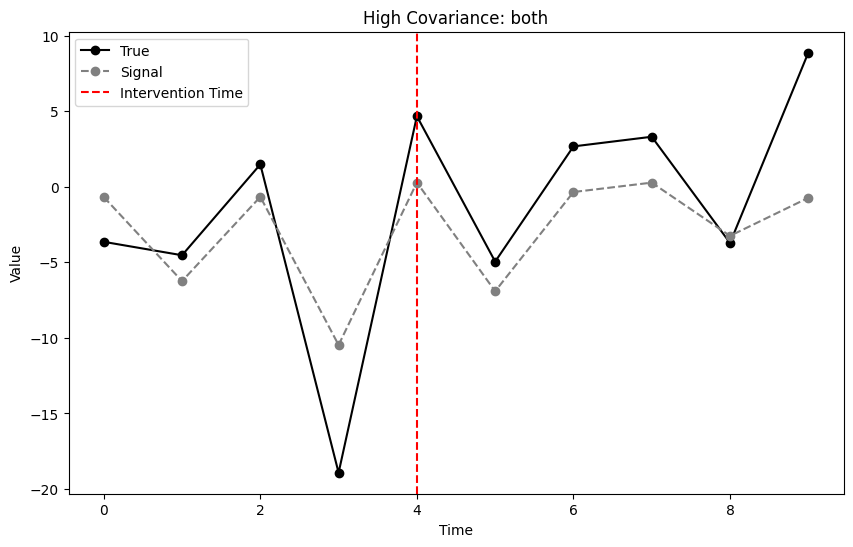

In [3]:
d_true = 2
d = 2
N, T = 3, 10
T0 = 4

seed_datagen = None
high_covariance = "both"

low = 1
high = 10

if high_covariance == "None":
    theta_true = gen_dirchelet_params(d=d_true, N=N, Q_diag=False, R_diag=False, random_seed=seed_datagen) #[A, H, Q, R, m0, P0]
elif high_covariance == "Q":
    theta_true = gen_dirchelet_params(d=d_true, N=N, noise_min_q=low, noise_max_q=high, Q_diag=False, R_diag=False, random_seed=seed_datagen) #[A, H, Q, R, m0, P0]
elif high_covariance == "R":
    theta_true = gen_dirchelet_params(d=d_true, N=N, noise_min_r=low, noise_max_r=high, Q_diag=False, R_diag=False, random_seed=seed_datagen) #[A, H, Q, R, m0, P0]
elif high_covariance == "both":
    theta_true = gen_dirchelet_params(d=d_true, N=N, noise_min_q=low, noise_max_q=high, noise_min_r=low, noise_max_r=high,Q_diag=False, R_diag=False, random_seed=seed_datagen) #[A, H, Q, R, m0, P0]

print(theta_true[2])
print(theta_true[3])
ys_signal, ys = generate_model_data(theta_true, T=T, return_signal=True, random_seed=seed_datagen) # T by N

plt.figure(figsize=(10,6))
plt.plot(ys[:,0], label='True',marker='o', color='black')
plt.plot(ys_signal[:,0], label='Signal', marker='o',color='gray', linestyle='--')
# plt.plot(rsc_pred, label='RSC', color='blue')
# plt.plot(sc_pred, label='SC', color='green')
# plt.plot(cim_pred, label='CIM', color='orange')
# plt.fill_between(np.arange(T), cim_posterior_lower, cim_posterior_upper, color='orange', alpha=0.3)
plt.axvline(x=T0, color='red', linestyle='--', label='Intervention Time')
plt.legend()
plt.title(f'High Covariance: {high_covariance}')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [4]:
A, H, Q, R, m0, P0 = theta_true
R

array([[ 25.14242039,   5.70300029, -25.47642506],
       [  5.70300029,  19.58057061,  19.2492935 ],
       [-25.47642506,  19.2492935 ,  60.06896066]])

In [5]:

# RSC baseline
rsc_pred = rsc_prediction(ys, T, T0, d, rscmethod='ridge', rsclmbda=0.1)

# SC baseline
sc_pred = synthetic_control_prediction(ys, T, T0)

# CIM baseline
# impact, cim_pred, cim_posterior_lower, cim_posterior_upper = cim_prediction(ys, T, T0)


In [6]:
seed_learning = 1000

In [ ]:
device = 'cpu'
set_seed(seed=seed_learning)
N1 = 1000

Y = torch.tensor(ys.T, dtype=torch.float32)    # (N, T)

######################
## OG TASC
Y_mask = Y.clone()  # (N, T)
Y_mask[0,T0:] = 0

model = TimeAwareSC(Y=Y_mask.to(device), d=d, device=device, dtype=torch.float32, learn_Q=True, learn_R=True)
model.initialize_theta(method='dirichlet', random_seed=seed_learning)
model.T0 = T0

# EM
model.em_pre(T0=T0, N1=N1)
logp = model.log_likelihood(T=T0).item()
with torch.no_grad():
    tasc_pred, donor_pred, target_var_estimates = model.make_prediction()
# tasc_pred
# target_var_estimates
tasc_upper = tasc_pred + 1.96 * torch.sqrt(target_var_estimates)
tasc_lower = tasc_pred - 1.96 * torch.sqrt(target_var_estimates)


In [8]:
model.initialize_theta(method='dirichlet', random_seed=1000)

print(model.A)
print(model.H)
print(model.Q)
print(model.R)
print(model.m0)
print(model.P0)

Parameter containing:
tensor([[-0.1879,  0.9822],
        [ 0.9822,  0.1879]], requires_grad=True)
Parameter containing:
tensor([[0.3913, 0.6087],
        [0.1799, 0.8201],
        [0.9392, 0.0608]], requires_grad=True)
tensor([[1.0327, 0.0000],
        [0.0000, 1.2125]], grad_fn=<AddBackward0>)
tensor([[1.0327, 0.0000, 0.0000],
        [0.0000, 1.2125, 0.0000],
        [0.0000, 0.0000, 2.3655]], grad_fn=<AddBackward0>)
Parameter containing:
tensor([0.5214, 0.6038], requires_grad=True)
tensor([[0.5242, 0.0286],
        [0.0286, 0.4922]], grad_fn=<AddBackward0>)


In [9]:
model.initialize_theta(method='dirichlet', random_seed=1005)

print(model.A)
print(model.H)
print(model.Q)
print(model.R)
print(model.m0)
print(model.P0)

Parameter containing:
tensor([[-0.7762, -0.6305],
        [-0.6305,  0.7762]], requires_grad=True)
Parameter containing:
tensor([[1.4794e-07, 1.0000e+00],
        [2.0768e-10, 1.0000e+00],
        [3.4287e-01, 6.5713e-01]], requires_grad=True)
tensor([[1.4428, 0.0000],
        [0.0000, 0.8625]], grad_fn=<AddBackward0>)
tensor([[1.4428, 0.0000, 0.0000],
        [0.0000, 0.8625, 0.0000],
        [0.0000, 0.0000, 1.3080]], grad_fn=<AddBackward0>)
Parameter containing:
tensor([0.0822, 0.9306], requires_grad=True)
tensor([[0.5292, 0.0375],
        [0.0375, 0.4945]], grad_fn=<AddBackward0>)


In [10]:
# tasc_pred
# target_var_estimates
tasc_upper = tasc_pred + 1.96 * torch.sqrt(target_var_estimates)
tasc_lower = tasc_pred - 1.96 * torch.sqrt(target_var_estimates)

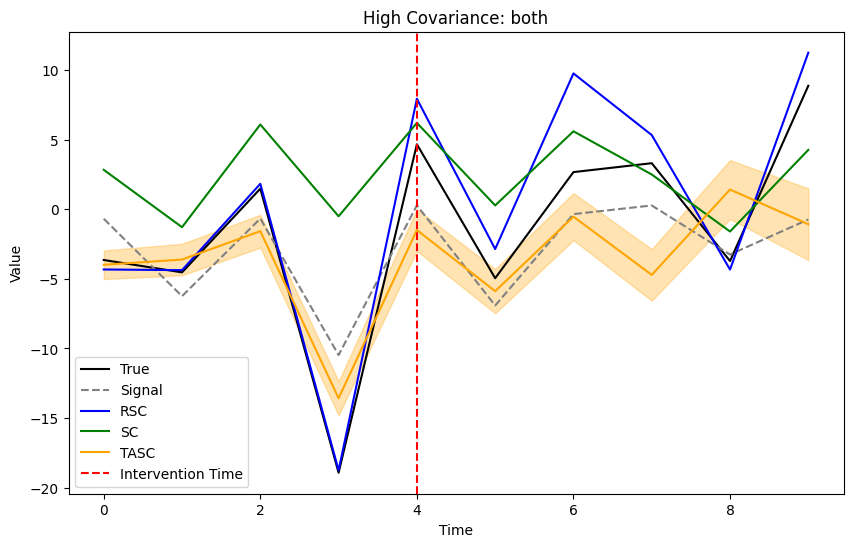

In [11]:
plt.figure(figsize=(10,6))
plt.plot(ys[:,0], label='True', color='black')
plt.plot(ys_signal[:,0], label='Signal', color='gray', linestyle='--')
plt.plot(rsc_pred, label='RSC', color='blue')
plt.plot(sc_pred, label='SC', color='green')
plt.plot(tasc_pred, label='TASC', color='orange')
plt.fill_between(np.arange(T), tasc_lower, tasc_upper, color='orange', alpha=0.3)
plt.axvline(x=T0, color='red', linestyle='--', label='Intervention Time')
plt.legend()
plt.title(f'High Covariance: {high_covariance}')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [ ]:

######################
## PERMUTE TASC
Y_permute= Y.clone()    # (N, T)
shuffler = IndexShuffler(n=Y_permute.size(1), seed=seed_learning)
Y_permute = Y_permute[:,shuffler.permutation]

model = TimeAwareSC(Y=Y_permute.to(device), d=d, device=device, dtype=torch.float32)
model.initialize_theta(method='dirichlet', random_seed=seed_learning)
model.T0 = T0

# EM
model.em_pre(T0=T0, N1=N1)
logp_permute = model.log_likelihood(T=T0).item()
with torch.no_grad():
    tasc_permute_pred, donor_pred, covar = model.make_prediction()
tasc_permute_pred = tasc_permute_pred[shuffler.inverse]

In [13]:
Y_permute= Y.clone()    # (N, T)

Y_permute

tensor([[ -3.6483,  -4.5364,   1.4742, -18.9233,   4.6620,  -4.9565,   2.6639,
           3.3024,  -3.7225,   8.8615],
        [  4.0473,  -2.8242,   9.4800,  -1.5198,   9.6677,  -0.2176,   8.6639,
           3.4903,  -3.3449,   6.4363],
        [ 14.9084,   1.4747,  18.6584,  20.1873,  12.1582,   4.8889,   8.1466,
           2.9653,   0.4047,   2.1039]])

In [14]:
T0=3
Y_permute= Y.clone() 
Y_pre = Y_permute[:,:T0]
shuffler_pre = IndexShuffler(n=T0)
Y_pre = Y_pre[:,shuffler_pre.permutation]


Y_post = Y_permute[:,T0:]
shuffler_post = IndexShuffler(n=T-T0)
Y_post = Y_post[:,shuffler_post.permutation]
Y_permute = torch.cat([Y_pre, Y_post], dim=1)

Y_permute

tensor([[ -4.5364,  -3.6483,   1.4742, -18.9233,  -3.7225,  -4.9565,   2.6639,
           3.3024,   8.8615,   4.6620],
        [ -2.8242,   4.0473,   9.4800,  -1.5198,  -3.3449,  -0.2176,   8.6639,
           3.4903,   6.4363,   9.6677],
        [  1.4747,  14.9084,  18.6584,  20.1873,   0.4047,   4.8889,   8.1466,
           2.9653,   2.1039,  12.1582]])

In [15]:
tasc_permute_pred

tensor([ 1.8635,  4.4326, -0.8261,  0.7367,  0.1841,  6.8179,  0.6293,  2.0410,
         6.4479,  2.6956])

In [16]:
tasc_permute_pred[T0:][shuffler_post.inverse]

tasc_permute_pred[T0:] = tasc_permute_pred[T0:][[1, 0]]

tasc_permute_pred

RuntimeError: The expanded size of the tensor (7) must match the existing size (2) at non-singleton dimension 0.  Target sizes: [7].  Tensor sizes: [2]

In [ ]:
shuffler_post.inverse

array([0, 1])

In [ ]:
n = 5
shuffler = IndexShuffler(n, seed=42)

arr = np.array([10, 20, 30, 40, 50])

shuffled = shuffler.shuffle(arr)
print("Shuffled:", shuffled)        # e.g., [30 50 40 10 20]

restored = shuffler.unshuffle(shuffled)
print("Restored:", restored)    

Shuffled: [50 30 40 20 10]
Restored: [10 20 30 40 50]
